# CIOOS data 

CIOOS standas for the the Canadian Integrated Ocean Observing System and similar to IOOS, is an repository of observational oceanographic data. 

Datasets from CIOOS was chosen by searching 'chl' in the two CIOOS ERDDAPS:
- https://data.cioospacific.ca/erddap/search/index.html?page=1&itemsPerPage=1000&searchFor=chl
- https://cioosatlantic.ca/erddap/search/index.html?page=1&itemsPerPage=1000&searchFor=chl

and only keeping extracted chlorophyll datsets. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime
import os
from matplotlib import ticker
import datetime as dt
import plotly.express as px
import cmocean as cm
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import time
import matplotlib.ticker as mticker

## Dataset 1 
data.cioospacific.ca/erddap/tabledap/IYS_NISKIN_chl_phaeo

In [2]:
url='https://data.cioospacific.ca/erddap/tabledap/IYS_NISKIN_chl_phaeo.nc?cruise%2Cstation%2Ctime%2Clatitude%2Clongitude%2Cdepth%2Cchlorophyll_a&time%3E=2019-03-07T00%3A00%3A00Z&time%3C=2019-03-14T15%3A59%3A00Z'
url = requests.get(url, verify=False).content
da = xr.open_dataset(url)
da1= da.to_dataframe() #so even though they do have a chla_calib, it looks like it's empty 
da1 = da1.rename(columns={'time': 'datetime','latitude':'lat','longitude':'lon','chlorophyll_a':'chl'}) 
da1['experiment'] = da.project 
da1['investigators']=da.publisher 
da1['affiliations']=da.institution
da1['DOI_url']= da.infoUrl
da1['HPLC'] = 1 
counts_series = da1[['depth','datetime','lat','lon']].value_counts() #count how many unique cast,depth, datetime, lat, and lons there are
da1['triplicate'] = 1 #based on inpsecting counts_series, no triplicates

NameError: name 'requests' is not defined

## Dataset 2 
https://data.cioospacific.ca/erddap/tabledap/IOS_BOT_Profiles

In [ ]:
url='https://data.cioospacific.ca/erddap/tabledap/IOS_BOT_Profiles.nc?mission_id%2Cscientist%2Cproject%2Cagency%2Cplatform%2Cinstrument_type%2Cinstrument_model%2Clatitude%2Clongitude%2Ctime%2Cdepth%2CCPHLFLP1&time%3E=2000-01-01&time%3C=2024-08-30T03%3A17%3A44Z'
url = requests.get(url, verify=False).content
da = xr.open_dataset(url)
da2= da.to_dataframe() #so even though they do have a chla_calib, it looks like it's empty 
da2 = da2.dropna(subset=['CPHLFLP1'])
da2 = da2.rename(columns={'scientist': 'investigators','project':'experiment','agency':'affiliations','platform':'station',
                          'latitude':'lat','longitude':'lon','time':'datetime','CPHLFLP1':'chl'}) 
counts_series = da2[['depth','datetime','lat','lon']].value_counts() #count how many unique cast,depth, datetime, lat, and lons there are
counts_df = counts_series.reset_index(name='freq_uniq')
da2 = pd.merge(da2, counts_df, on=['depth','datetime','lat','lon'], how='left') #add frequency column to original dataframe

#sometimes, triplicate specific times are recorded (ex: 3:00, 3:05, 3:10 ), so also check for unique datehour entries
da2['date_hour'] = da2['datetime'].dt.strftime('%Y-%m-%d %H')
counts_series = da2[['depth','date_hour','lat','lon']].value_counts() #count how many unique datehour, lat, and lons there are
counts_df = counts_series.reset_index(name='freq_hour')
da2 = pd.merge(da2, counts_df, on=['depth','date_hour','lat','lon'], how='left') #add frequency column to original dataframe
da2['triplicate'] = 1 #assume bad unless otherwise said
da2.loc[da2['freq_uniq'] == 3, 'triplicate'] = 0 #if there was a unique datetime, lat, and lon that happened 3 times, triplicate
da2.loc[(da2['freq_uniq'] == 1) &(da2['freq_hour'] == 3), 'triplicate'] = 0 #if 1 unique datetime but 3 unique date hours, assume triplicate

da2=da2[['investigators', 'experiment', 'affiliations', 'station', 'lat', 'lon', 'datetime', 'depth', 'chl', 'triplicate']]
da2['HPLC'] = 1
da2['DOI_url']='https://data.cioospacific.ca/erddap/tabledap/IOS_BOT_Profiles'
da2=da2.loc[da2['depth']<=150].reset_index(drop=True) 
da2 = da2[da2['chl'] >= 0]

## Dataset 3
cioosatlantic.ca/erddap/tabledap/bio_atlantic_zone_monitoring_program_bottle_bbmp

In [ ]:
url='https://cioosatlantic.ca/erddap/tabledap/bio_atlantic_zone_monitoring_program_bottle_bbmp.nc?mission_descriptor%2Cinstitute%2Cstation%2Clatitude%2Clongitude%2Ctime%2Cdepth%2CChlorophyll_A%2CHPLC_chlorophyll_a&time%3E=2000-01-01&time%3C=2024-12-31T13%3A19%3A00Z'
url = requests.get(url, verify=False).content
da = xr.open_dataset(url)
da3= da.to_dataframe()
da3=da3.dropna(subset=['Chlorophyll_A', 'HPLC_chlorophyll_a'], how='all')
da3 = da3.rename(columns={'mission_descriptor': 'cruise','institute':'affiliations','HPLC_chlorophyll_a':'chl_a',
                          'latitude':'lat','longitude':'lon','time':'datetime','Chlorophyll_A':'chl'}) 
#so some chl and chl_a values are shifted down. so while they should be coincidental they instead populate nan and are shifted down. need to re aling them to show side by side comparison 
metadata_cols = ['cruise', 'affiliations', 'station', 'lat', 'lon', 'datetime', 'depth']
da3 = da3.groupby(metadata_cols, as_index=False).first()
da3['experiment'] = da.program 
da3['investigators']=da.chief_scientist 
da3['affiliations']=da.institution
da3['DOI_url']= da.publisher_url
#so some chl and chl_a values are shifted down. so while they should be coincidental they instead populate nan and are shifted down. need to re aling them to show side by side comparison 
#HPLC
da3['HPLC'] = 0 #initiate all columns as good, only empty values will be 1 
da3.loc[da3['chl_a'].isna(), 'HPLC'] = 1
counts_series = da3[['depth','datetime','lat','lon']].value_counts() #count how many unique cast,depth, datetime, lat, and lons there are
da3['triplicate'] = 1 #based on inpsecting counts_series, no triplicates

In [ ]:
df_combined = pd.concat([da1, da2,da3], ignore_index=True)


In [ ]:
shp = gpd.read_file(r'C:\Users\gianna.milton\Documents\Python\Shapefiles\combined_coastline.shp')
gdf = gpd.GeoDataFrame(df_combined, geometry=gpd.points_from_xy(df_combined.lon, df_combined.lat), crs="EPSG:4269")
gdf = gdf.to_crs(shp.crs)
df_combined = gpd.sjoin(gdf, shp, how="inner", predicate="within")
columns_to_drop = ['geometry', 'index_right', 'merge_id']
df_combined = df_combined.drop(columns=columns_to_drop)
df_combined= df_combined.reset_index(drop=True)

Done with CIOOS data. 

# Plots

In [2]:
cioos = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\CIOOS_chl.xlsx')

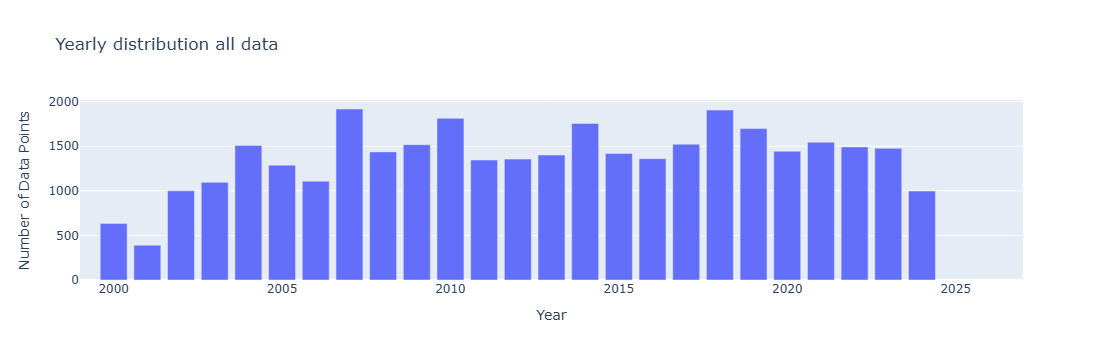

In [3]:
year_test=cioos.copy()
year_test['date'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['date'].dt.year
grouped = year_test.groupby(['year']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(grouped,x='year', y='DataPoints', title='Yearly distribution all data',
             labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

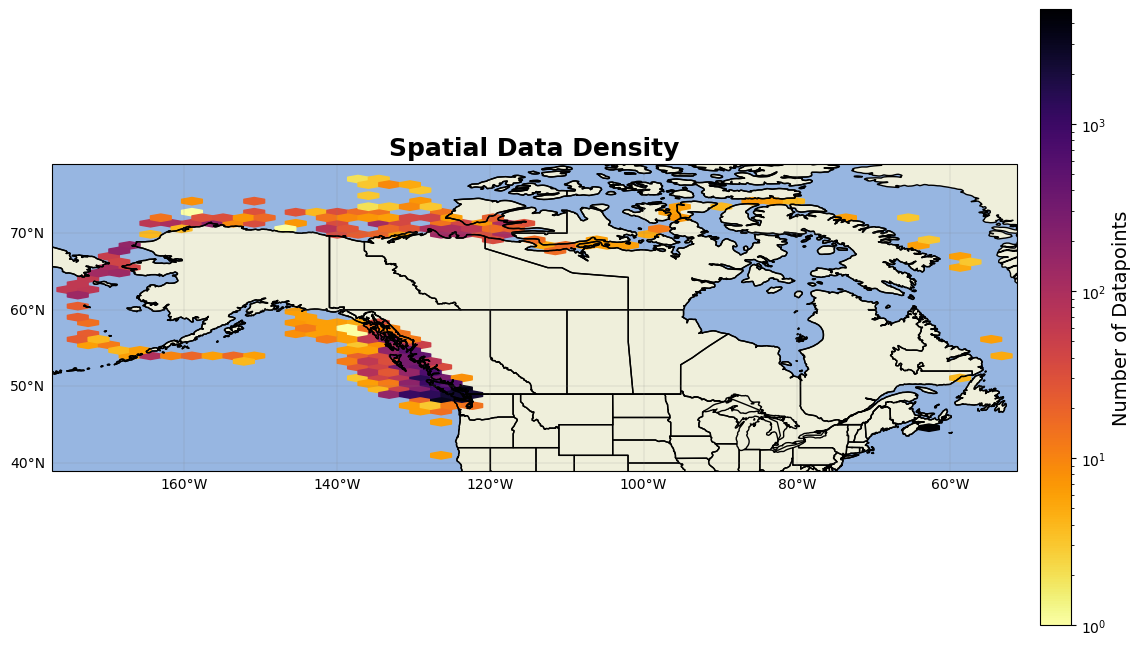

In [6]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(year_test.lon, year_test.lat, gridsize=45, cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('Number of Datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_xlim(min(year_test.lon)-2,max(year_test.lon)+2)
ax.set_ylim(min(year_test.lat)-2,max(year_test.lat)+2)

ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()